In [1]:
# ============================================================
# STEP 0: UNZIPPING DATASET AND READY FOR USE
# ============================================================

!unzip -q anatomy_dataset.zip -d /content

In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
!pip install albumentations

In [5]:
# ============================================================
# STEP 1: IMPORTS & CONFIG
# ============================================================
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= PATHS =================
DATASET_ROOT = "/content/DATASET"
MODEL_DIR = "/content/DEEPLAB V3 MODEL"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = f"{MODEL_DIR}/best_deeplabv3.pth"

# ================= TRAINING CONFIG =================
NUM_CLASSES = 8   # background + 7 organs
BATCH_SIZE = 1 # Reduced from 4 to 2 to conserve GPU memory
LR = 1e-4
EPOCHS = 50
PATIENCE = 10
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [6]:
# ============================================================
# STEP 2: DATASET CLASS
# ============================================================
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

        if augment:
            self.tf = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Normalize(),
                ToTensorV2()
            ])
        else:
            self.tf = A.Compose([
                A.Normalize(),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, name)),
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        img = cv2.resize(img, (384, 384), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (384, 384), interpolation=cv2.INTER_NEAREST)

        aug = self.tf(image=img, mask=mask)
        img, mask = aug["image"], aug["mask"]

        # ---- ORGAN PRESENCE VECTOR ----
        presence = torch.zeros(NUM_CLASSES)
        for c in range(1, NUM_CLASSES):
            if torch.any(mask == c):
                presence[c] = 1.0

        return img, mask.long(), presence

In [12]:
# ============================================================
# STEP 3: DEEPLABV3 MODEL
# ============================================================

import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet101

def get_deeplabv3(num_classes):
    model = deeplabv3_resnet101(weights="DEFAULT")

    # Replace final classifier
    model.classifier[4] = nn.Conv2d(
        in_channels=256,
        out_channels=num_classes,
        kernel_size=1
    )

    return model

In [13]:
# ============================================================
# STEP 4: LOSSES (UNCHANGED)
# ============================================================

class_weights = torch.tensor(
    [1.0, 1.0, 1.0, 2.0, 6.0, 3.0, 2.0, 1.0],
    device=device
)

class WeightedDiceLoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.weights = weights

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum((2,3))
        union = pred.sum((2,3)) + target.sum((2,3))
        dice = (2 * inter + 1e-5) / (union + 1e-5)
        return 1 - (dice * self.weights).sum() / self.weights.sum()

seg_dice_loss = WeightedDiceLoss(class_weights)
seg_bce_loss  = nn.BCEWithLogitsLoss()

In [14]:
# ============================================================
# STEP 5: LOAD DATA
# ============================================================
train_ds = SegDataset(
    f"{DATASET_ROOT}/TRAIN/IMAGE",
    f"{DATASET_ROOT}/TRAIN/MASK",
    augment=True
)

val_ds = SegDataset(
    f"{DATASET_ROOT}/VALIDATION/IMAGE",
    f"{DATASET_ROOT}/VALIDATION/MASK"
)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2)


In [15]:
import torch
print(torch.cuda.is_available())

True


In [17]:
# ============================================================
# STEP 6: TRAINING LOOP & EARLY STOPING
# ============================================================
from torch.amp import autocast, GradScaler

model = get_deeplabv3(NUM_CLASSES).to(device)


def convert_bn_to_gn(model, max_groups=32):
    for name, module in model.named_children():
        if isinstance(module, nn.BatchNorm2d):
            channels = module.num_features
            groups = min(max_groups, channels)
            while channels % groups != 0:
                groups -= 1
            setattr(model, name, nn.GroupNorm(groups, channels))
        else:
            convert_bn_to_gn(module, max_groups)

convert_bn_to_gn(model)
model = model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)
scaler = GradScaler(enabled=torch.cuda.is_available())

best_val_loss = float("inf")
wait = 0

history = {"train_loss": [], "val_loss": []}
dice_history = {"small_intestine": [], "stomach": []}

def dice_per_class(pred, target, eps=1e-5):
    pred = (torch.sigmoid(pred) > 0.5)
    inter = (pred & target.bool()).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean(dim=0)   # 🔑 returns [C]

for epoch in range(EPOCHS):

    print(f"\n================ Epoch {epoch+1}/{EPOCHS} ================")

    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc="Training",
        leave=False
    )

    for x, seg_gt, _ in train_bar:
        x = x.to(device)
        seg_gt = seg_gt.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            seg_out = model(x)["out"]

            seg_gt_oh = torch.nn.functional.one_hot(
                seg_gt, NUM_CLASSES
            ).permute(0,3,1,2).float()

            loss = (
                3.0 * seg_dice_loss(seg_out, seg_gt_oh) +
                0.5 * seg_bce_loss(seg_out, seg_gt_oh)
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0
    dice_si_epoch, dice_st_epoch = [], []

    val_bar = tqdm(
        val_loader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():
        for x, seg_gt, _ in val_bar:
            x = x.to(device)
            seg_gt = seg_gt.to(device)

            with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                seg_out = model(x)["out"]

                seg_gt_oh = torch.nn.functional.one_hot(
                    seg_gt, NUM_CLASSES
                ).permute(0,3,1,2).float()

                loss = (
                    3.0 * seg_dice_loss(seg_out, seg_gt_oh) +
                    0.5 * seg_bce_loss(seg_out, seg_gt_oh)
                )

                val_loss += loss.item()

                dice_vals = dice_per_class(seg_out, seg_gt_oh)

                if seg_gt_oh[:,5].sum() > 0:
                    dice_si_epoch.append(dice_vals[5].item())
                if seg_gt_oh[:,7].sum() > 0:
                    dice_st_epoch.append(dice_vals[7].item())

    val_loss /= len(val_loader)

    # ===================== SUMMARY =====================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    si_dice = np.mean(dice_si_epoch) if dice_si_epoch else 0.0
    st_dice = np.mean(dice_st_epoch) if dice_st_epoch else 0.0

    dice_history["small_intestine"].append(si_dice)
    dice_history["stomach"].append(st_dice)

    print(
        f"Epoch {epoch+1} Summary | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"SI Dice: {si_dice:.3f} | "
        f"ST Dice: {st_dice:.3f}"
    )

    # ===================== EARLY STOPPING =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        wait = 0
        print("✅ Model improved — saved checkpoint")
    else:
        wait += 1
        print(f"⚠️ No improvement ({wait}/{PATIENCE})")
        if wait >= PATIENCE:
            print("⛔ Early stopping triggered")
            break


================ Epoch 1/50 ================


Epoch 1 Summary | Train Loss: 2.7798 | Val Loss: 2.7121 | SI Dice: 0.691 | ST Dice: 0.434
✅ Model improved — saved checkpoint

================ Epoch 2/50 ================


Epoch 2 Summary | Train Loss: 2.6859 | Val Loss: 2.6898 | SI Dice: 0.695 | ST Dice: 0.490
✅ Model improved — saved checkpoint

================ Epoch 3/50 ================


Epoch 3 Summary | Train Loss: 2.6591 | Val Loss: 2.6345 | SI Dice: 0.271 | ST Dice: 0.520
✅ Model improved — saved checkpoint

================ Epoch 4/50 ================


Epoch 4 Summary | Train Loss: 2.6360 | Val Loss: 2.6238 | SI Dice: 0.737 | ST Dice: 0.517
✅ Model improved — saved checkpoint

================ Epoch 5/50 ================


...

Epoch 46 Summary | Train Loss: 2.3677 | Val Loss: 2.4138 | SI Dice: 0.822 | ST Dice: 0.783
✅ Model improved — saved checkpoint

================ Epoch 47/50 ================


Epoch 47 Summary | Train Loss: 2.3684 | Val Loss: 2.4421 | SI Dice: 0.844 | ST Dice: 0.722
⚠️ No improvement (1/10)

================ Epoch 48/50 ================


Epoch 48 Summary | Train Loss: 2.3661 | Val Loss: 2.4185 | SI Dice: 0.655 | ST Dice: 0.767
⚠️ No improvement (2/10)

================ Epoch 49/50 ================


Epoch 49 Summary | Train Loss: 2.3627 | Val Loss: 2.4192 | SI Dice: 0.765 | ST Dice: 0.784
⚠️ No improvement (3/10)

================ Epoch 50/50 ================


Epoch 50 Summary | Train Loss: 2.3657 | Val Loss: 2.4293 | SI Dice: 0.816 | ST Dice: 0.763
⚠️ No improvement (4/10)


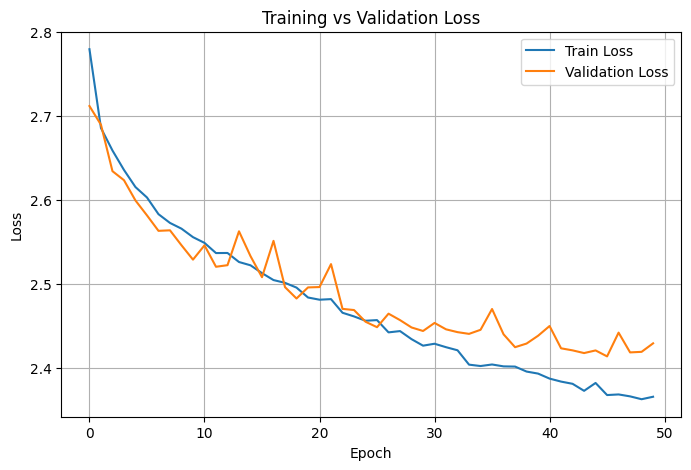

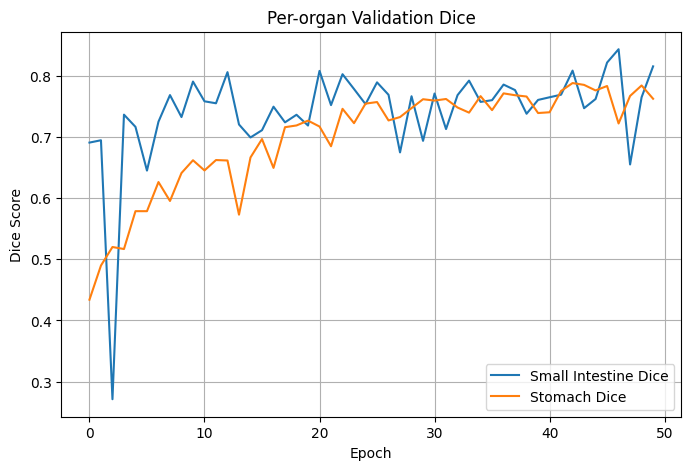

In [18]:
# ============================================================
# STEP 7: CURVES (FINAL)
# ============================================================

# ---- Loss Curves ----
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Per-organ Dice Curves ----
plt.figure(figsize=(8,5))
plt.plot(dice_history["small_intestine"], label="Small Intestine Dice")
plt.plot(dice_history["stomach"], label="Stomach Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Per-organ Validation Dice")
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# ============================================================
# STEP 8: TESTING (DEEPLABV3 – FIXED)
# ============================================================

def convert_bn_to_gn(model, groups=32):
    for name, module in model.named_children():
        if isinstance(module, nn.BatchNorm2d):
            setattr(model, name, nn.GroupNorm(groups, module.num_features))
        else:
            convert_bn_to_gn(module, groups)

# ---- rebuild model EXACTLY like training ----
model = get_deeplabv3(NUM_CLASSES)
convert_bn_to_gn(model)      # 🔑 THIS IS THE KEY
model = model.to(device)

# ---- load checkpoint ----
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ DeepLabV3 + GroupNorm model loaded correctly")

✅ DeepLabV3 + GroupNorm model loaded correctly


In [47]:
# ---- Class-wise thresholds (important for rare organs) ----
thresholds = {
    1: 0.30,  # abdominal_wall
    2: 0.30,  # colon
    3: 0.30,  # liver
    4: 0.20,  # pancreas
    5: 0.25,  # small_intestine
    6: 0.30,  # spleen
    7: 0.35,  # stomach
}

In [48]:
# ---- Dice storage ----
dice_scores = {i: [] for i in range(NUM_CLASSES)}

def dice_per_class(pred, target, eps=1e-5):
    inter = (pred & target).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return (2 * inter + eps) / (union + eps)

In [49]:
# ---- Testing loop ----

# ---- Metric accumulators (pixel-wise) ----
tp = torch.zeros(NUM_CLASSES)
fp = torch.zeros(NUM_CLASSES)
fn = torch.zeros(NUM_CLASSES)
tn = torch.zeros(NUM_CLASSES)

with torch.no_grad():
    for x, seg_gt, _ in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        seg_gt = seg_gt.to(device)   # (1,H,W)

        seg_out = model(x)["out"]    # (1,C,H,W)
        prob = torch.sigmoid(seg_out)

        # ---- Threshold per class ----
        pred = torch.zeros_like(prob, dtype=torch.int)
        for c in range(NUM_CLASSES):
            th = thresholds.get(c, 0.5)
            pred[:, c] = (prob[:, c] > th).int()

        # ---- GT one-hot ----
        gt_oh = torch.nn.functional.one_hot(
            seg_gt, NUM_CLASSES
        ).permute(0,3,1,2).int()

        pred_bin = pred.bool()
        gt_bin   = gt_oh.bool()

        for c in range(NUM_CLASSES):
            tp[c] += torch.logical_and(pred_bin[:, c], gt_bin[:, c]).sum().cpu()
            fp[c] += torch.logical_and(pred_bin[:, c], ~gt_bin[:, c]).sum().cpu()
            fn[c] += torch.logical_and(~pred_bin[:, c], gt_bin[:, c]).sum().cpu()
            tn[c] += torch.logical_and(~pred_bin[:, c], ~gt_bin[:, c]).sum().cpu()

        dice = dice_per_class(pred, gt_oh)

        # ---- Presence-aware dice ----
        for c in range(NUM_CLASSES):
            if gt_oh[:, c].sum() > 0:
                dice_scores[c].append(dice[:, c].item())

Testing: 100%|██████████| 72/72 [00:08<00:00,  8.84it/s]


In [50]:
# ---- Print results ----
print("\n===== TEST RESULTS (Presence-aware Dice) =====")

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

for c, name in enumerate(CLASS_NAMES):
    if len(dice_scores[c]) > 0:
        print(f"{name:20s} : {np.mean(dice_scores[c]):.4f}")
    else:
        print(f"{name:20s} : N/A (not present)")


===== TEST RESULTS (Presence-aware Dice) =====
background           : 0.9495
abdominal_wall       : 0.7778
colon                : 0.6363
liver                : 0.7144
pancreas             : 0.5015
small_intestine      : 0.9571
spleen               : 0.8431
stomach              : 0.8374


In [51]:
eps = 1e-7

precision = tp / (tp + fp + eps)
recall    = tp / (tp + fn + eps)
dice_all  = (2 * tp) / (2 * tp + fp + fn + eps)
iou       = tp / (tp + fp + fn + eps)
accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)
f1        = dice_all  # Dice == F1 for segmentation

print("\n===== FULL SEGMENTATION EVALUATION =====\n")
print(f"{'Class':20s} | Acc | Prec | Recall | Dice | IoU")
print("-" * 70)

for c, name in enumerate(CLASS_NAMES):
    print(
        f"{name:20s} | "
        f"{accuracy[c]:.3f} | "
        f"{precision[c]:.3f} | "
        f"{recall[c]:.3f} | "
        f"{dice_all[c]:.3f} | "
        f"{iou[c]:.3f}"
    )

print("\n===== OVERALL MODEL PERFORMANCE =====")
print(f"Mean Accuracy : {accuracy[1:].mean():.4f}")
print(f"Mean Precision: {precision[1:].mean():.4f}")
print(f"Mean Recall   : {recall[1:].mean():.4f}")
print(f"Mean Dice     : {dice_all[1:].mean():.4f}")
print(f"Mean IoU      : {iou[1:].mean():.4f}")



===== FULL SEGMENTATION EVALUATION =====

Class                | Acc | Prec | Recall | Dice | IoU
----------------------------------------------------------------------
background           | 0.950 | 0.960 | 0.977 | 0.968 | 0.939
abdominal_wall       | 0.972 | 0.786 | 0.902 | 0.840 | 0.724
colon                | 0.988 | 0.632 | 0.757 | 0.689 | 0.526
liver                | 0.988 | 0.752 | 0.902 | 0.820 | 0.695
pancreas             | 0.990 | 0.188 | 0.456 | 0.266 | 0.154
small_intestine      | 0.994 | 0.292 | 0.961 | 0.448 | 0.288
spleen               | 0.995 | 0.415 | 0.932 | 0.574 | 0.403
stomach              | 0.981 | 0.910 | 0.822 | 0.864 | 0.760

===== OVERALL MODEL PERFORMANCE =====
Mean Accuracy : 0.9870
Mean Precision: 0.5678
Mean Recall   : 0.8190
Mean Dice     : 0.6431
Mean IoU      : 0.5072


In [44]:
# ============================================================
# STEP 9: SINGLE IMAGE TESTING (DEEPLABV3 – FIXED)
# ============================================================

import matplotlib.pyplot as plt

def convert_bn_to_gn(model, groups=32):
    for name, module in model.named_children():
        if isinstance(module, nn.BatchNorm2d):
            setattr(model, name, nn.GroupNorm(groups, module.num_features))
        else:
            convert_bn_to_gn(module, groups)

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

COLORS = {
    1: (255, 0, 0),
    2: (0, 255, 0),
    3: (0, 0, 255),
    4: (255, 255, 0),
    5: (255, 0, 255),
    6: (0, 255, 255),
    7: (255, 165, 0),
}

COLOR_NAMES = {
    1: "Red",        # abdominal_wall
    2: "Green",      # colon
    3: "Blue",       # liver
    4: "Yellow",     # pancreas
    5: "Magenta",    # small_intestine
    6: "Cyan",       # spleen
    7: "Orange",     # stomach
}

# ---- rebuild model EXACTLY like Step 8 ----
model = get_deeplabv3(NUM_CLASSES)
convert_bn_to_gn(model)
model = model.to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

def test_single_image(image_path, model, device):
    model.eval()

    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    # 🔑 SAME normalization as training
    img_tensor = (
        torch.from_numpy(img_resized)
        .permute(2, 0, 1)
        .float()
        / 255.0
    )

    img_tensor = (img_tensor - 0.5) / 0.5   # match Albumentations Normalize
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img_tensor)["out"]
        prob = torch.sigmoid(out)[0]

    overlay = img_resized.copy()
    detected = []

    for c in range(1, NUM_CLASSES):
        th = thresholds.get(c, 0.3)
        mask = (prob[c] > th).cpu().numpy()

        if mask.sum() > 20:
            detected.append((CLASS_NAMES[c], COLOR_NAMES[c]))
            overlay[mask] = (
                0.6 * overlay[mask] + 0.4 * np.array(COLORS[c])
            )

    print("Max probability per class:")
    for c in range(1, NUM_CLASSES):
        print(CLASS_NAMES[c], float(prob[c].max()))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_resized)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Predicted Segmentation")
    plt.axis("off")
    plt.show()

    print("🧠 Detected Anatomies:")
    for name, color in detected:
        print(f" - {name} ({color})")

Max probability per class:
abdominal_wall 0.9988191723823547
colon 0.9996342658996582
liver 0.9997840523719788
pancreas 0.9998206496238708
small_intestine 0.3588006794452667
spleen 0.8076838850975037
stomach 0.9998216032981873


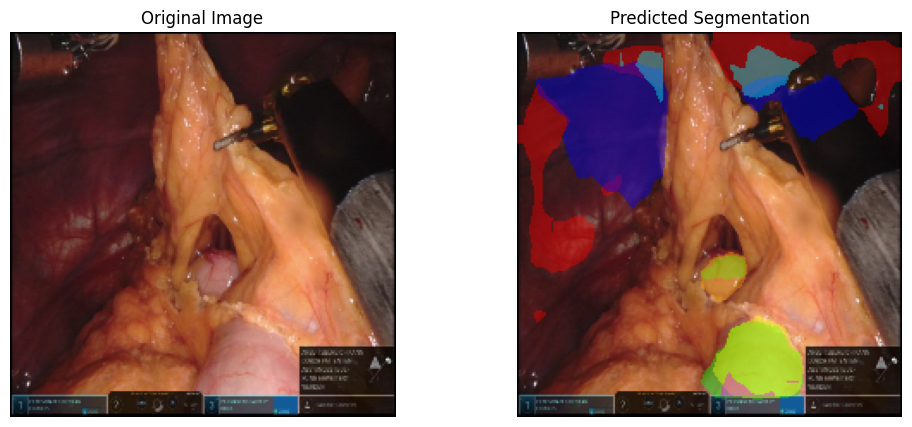

🧠 Detected Anatomies:
 - abdominal_wall (Red)
 - colon (Green)
 - liver (Blue)
 - pancreas (Yellow)
 - small_intestine (Magenta)
 - spleen (Cyan)
 - stomach (Orange)


In [ ]:
# ---- Run ----
test_single_image(
    image_path="/content/DATASET/TEST/IMAGE/img013.png",
    model=model,
    device=device
)